In [1]:
#Importing initial packages
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import pickle
import joblib

# Reading the dataset

In [3]:
# Read the CSV file containing the turbine dataset
data = pd.read_csv("diamonds.csv")
# Display the first 5 rows of the dataset
data.head()

,Unnamed: 0,cut,color,clarity,carat_weight,cut_quality,lab,symmetry,polish,eye_clean,...,meas_depth,girdle_min,girdle_max,fluor_color,fluor_intensity,fancy_color_dominant_color,fancy_color_secondary_color,fancy_color_overtone,fancy_color_intensity,total_sales_price
0,0,Round,E,VVS2,0.09,Excellent,IGI,Very Good,Very Good,unknown,...,1.79,M,M,unknown,NaN,unknown,unknown,unknown,unknown,200
1,1,Round,E,VVS2,0.09,Very Good,IGI,Very Good,Very Good,unknown,...,1.78,STK,STK,unknown,NaN,unknown,unknown,unknown,unknown,200
2,2,Round,E,VVS2,0.09,Excellent,IGI,Very Good,Very Good,unknown,...,1.77,TN,M,unknown,NaN,unknown,unknown,unknown,unknown,200
3,3,Round,E,VVS2,0.09,Excellent,IGI,Very Good,Very Good,unknown,...,1.78,M,STK,unknown,NaN,unknown,unknown,unknown,unknown,200
4,4,Round,E,VVS2,0.09,Very Good,IGI,Very Good,Excellent,unknown,...,1.82,STK,STK,unknown,NaN,unknown,unknown,unknown,unknown,200


In [4]:
# The info() function provides a concise summary of the DataFrame.
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 219703 entries, 0 to 219702
Data columns (total 26 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Unnamed: 0                   219703 non-null  int64  
 1   cut                          219703 non-null  object 
 2   color                        219703 non-null  object 
 3   clarity                      219703 non-null  object 
 4   carat_weight                 219703 non-null  float64
 5   cut_quality                  219703 non-null  object 
 6   lab                          219703 non-null  object 
 7   symmetry                     219703 non-null  object 
 8   polish                       219703 non-null  object 
 9   eye_clean                    219703 non-null  object 
 10  culet_size                   219703 non-null  object 
 11  culet_condition              219703 non-null  object 
 12  depth_percent                219703 non-null  float64
 13 

# Data Preprocessing

In [6]:
#checking for null values in the dataset
data.isnull().sum()

Unnamed: 0                          0
cut                                 0
color                               0
clarity                             0
carat_weight                        0
cut_quality                         0
lab                                 0
symmetry                            0
polish                              0
eye_clean                           0
culet_size                          0
culet_condition                     0
depth_percent                       0
table_percent                       0
meas_length                         0
meas_width                          0
meas_depth                          0
girdle_min                          0
girdle_max                          0
fluor_color                         0
fluor_intensity                143491
fancy_color_dominant_color          0
fancy_color_secondary_color         0
fancy_color_overtone             1650
fancy_color_intensity               0
total_sales_price                   0
dtype: int64

In [7]:
# The column 'Unnamed: 0' is commonly created when a DataFrame
# The drop() function removes this column from the dataset.
data = data.drop(columns='Unnamed: 0')

In [8]:
# Display the first 5 rows of the dataset
data.head()

,cut,color,clarity,carat_weight,cut_quality,lab,symmetry,polish,eye_clean,culet_size,...,meas_depth,girdle_min,girdle_max,fluor_color,fluor_intensity,fancy_color_dominant_color,fancy_color_secondary_color,fancy_color_overtone,fancy_color_intensity,total_sales_price
0,Round,E,VVS2,0.09,Excellent,IGI,Very Good,Very Good,unknown,N,...,1.79,M,M,unknown,NaN,unknown,unknown,unknown,unknown,200
1,Round,E,VVS2,0.09,Very Good,IGI,Very Good,Very Good,unknown,N,...,1.78,STK,STK,unknown,NaN,unknown,unknown,unknown,unknown,200
2,Round,E,VVS2,0.09,Excellent,IGI,Very Good,Very Good,unknown,unknown,...,1.77,TN,M,unknown,NaN,unknown,unknown,unknown,unknown,200
3,Round,E,VVS2,0.09,Excellent,IGI,Very Good,Very Good,unknown,unknown,...,1.78,M,STK,unknown,NaN,unknown,unknown,unknown,unknown,200
4,Round,E,VVS2,0.09,Very Good,IGI,Very Good,Excellent,unknown,N,...,1.82,STK,STK,unknown,NaN,unknown,unknown,unknown,unknown,200


In [9]:
# Count the number of unique values in each column of the dataset
# This helps understand the variability of each featur
data.nunique()

cut                               11
color                             11
clarity                           11
carat_weight                     878
cut_quality                        6
lab                                3
symmetry                           5
polish                             5
eye_clean                          5
culet_size                         9
culet_condition                    4
depth_percent                    534
table_percent                    235
meas_length                     1415
meas_width                      1155
meas_depth                       852
girdle_min                        10
girdle_max                        10
fluor_color                        6
fluor_intensity                    7
fancy_color_dominant_color        13
fancy_color_secondary_color       11
fancy_color_overtone               8
fancy_color_intensity             10
total_sales_price              22202
dtype: int64

In [10]:
#Deleting any duplicated rows
data[data.duplicated()]
data = data.drop_duplicates()
data

,cut,color,clarity,carat_weight,cut_quality,lab,symmetry,polish,eye_clean,culet_size,...,meas_depth,girdle_min,girdle_max,fluor_color,fluor_intensity,fancy_color_dominant_color,fancy_color_secondary_color,fancy_color_overtone,fancy_color_intensity,total_sales_price
0,Round,E,VVS2,0.09,Excellent,IGI,Very Good,Very Good,unknown,N,...,1.79,M,M,unknown,NaN,unknown,unknown,unknown,unknown,200
1,Round,E,VVS2,0.09,Very Good,IGI,Very Good,Very Good,unknown,N,...,1.78,STK,STK,unknown,NaN,unknown,unknown,unknown,unknown,200
2,Round,E,VVS2,0.09,Excellent,IGI,Very Good,Very Good,unknown,unknown,...,1.77,TN,M,unknown,NaN,unknown,unknown,unknown,unknown,200
3,Round,E,VVS2,0.09,Excellent,IGI,Very Good,Very Good,unknown,unknown,...,1.78,M,STK,unknown,NaN,unknown,unknown,unknown,unknown,200
4,Round,E,VVS2,0.09,Very Good,IGI,Very Good,Excellent,unknown,N,...,1.82,STK,STK,unknown,NaN,unknown,unknown,unknown,unknown,200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
219698,Round,E,VS1,10.65,Excellent,GIA,Excellent,Excellent,unknown,N,...,8.66,M,STK,unknown,NaN,unknown,unknown,unknown,unknown,1210692
219699,Radiant,unknown,VS2,5.17,unknown,GIA,Very Good,Very Good,unknown,unknown,...,5.71,TK,XTK,unknown,NaN,Green,unknown,NaN,Fancy Light,1292500
219700,Round,E,VS1,18.07,Excellent,GIA,Excellent,Excellent,unknown,N,...,10.20,TN,M,unknown,NaN,unknown,unknown,unknown,unknown,1315496
219701,Princess,unknown,SI2,0.90,unknown,GIA,Good,Good,unknown,N,...,3.47,XTN,VTK,unknown,Faint,Red,unknown,unknown,Fancy,1350000


In [11]:
# Changing categorical values by encoding using Label encoder
from sklearn.preprocessing import LabelEncoder

In [12]:
# Create a LabelEncoder instance to convert categorical values into numbers
lnc = LabelEncoder()

# Create a copy of the dataset to avoid modifying the original data
df = data.copy()

# Loop through each column in the dataset
for i in data:
    r = data[i].dtypes
    
    # Check if the column is categorical (object type)
    if r == 'object':
        
        # Convert categorical values to numeric labels
        df[i] = lnc.fit_transform(data[i])
        
        # Save the fitted encoder for future use (e.g., when predicting new data)
        joblib.dump(lnc, i + '.joblib', compress=9)

In [13]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 215823 entries, 0 to 219702
Data columns (total 25 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   cut                          215823 non-null  int32  
 1   color                        215823 non-null  int32  
 2   clarity                      215823 non-null  int32  
 3   carat_weight                 215823 non-null  float64
 4   cut_quality                  215823 non-null  int32  
 5   lab                          215823 non-null  int32  
 6   symmetry                     215823 non-null  int32  
 7   polish                       215823 non-null  int32  
 8   eye_clean                    215823 non-null  int32  
 9   culet_size                   215823 non-null  int32  
 10  culet_condition              215823 non-null  int32  
 11  depth_percent                215823 non-null  float64
 12  table_percent                215823 non-null  float64
 13  meas

# Outlier detection

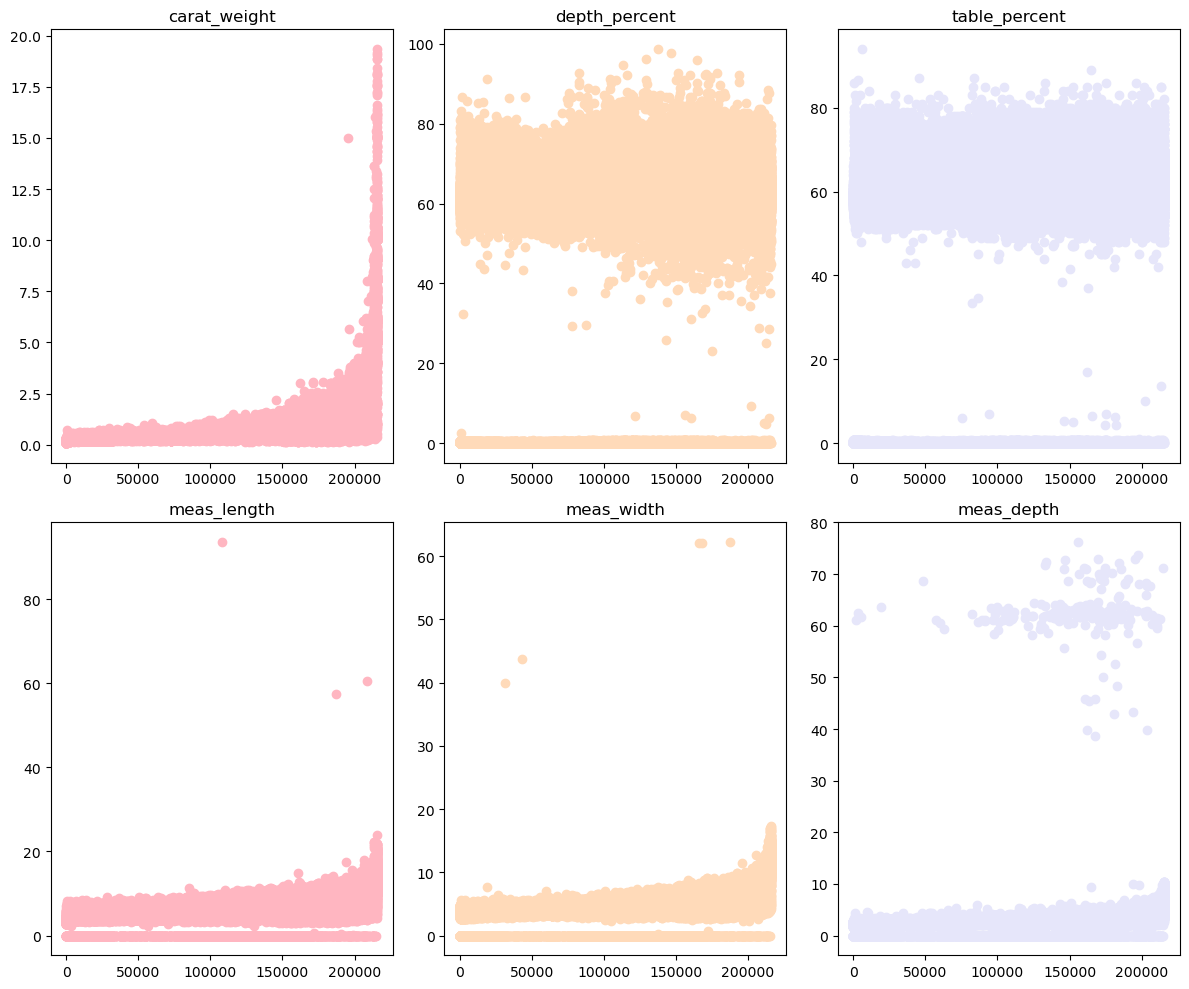

In [44]:
# =========================================
# Plot numeric features to explore data
# =========================================

# Select pastel colors
colors = ['#FFB6C1','#FFDAB9','#E6E6FA','#FFB6C1','#FFDAB9','#E6E6FA']

# Select float columns
float_cols = [i for i in df if df[i].dtype == 'float64']

# Create 3x2 grid for plots
fig, axes = plt.subplots(2, 3, figsize=(12,10))
axes = axes.flatten()

# Loop through numeric columns
for idx, col in enumerate(float_cols):
    
    # Scatter plot of values vs index
    axes[idx].scatter(range(len(df[col])), df[col], color=colors[idx])
    
    # Title for each plot
    axes[idx].set_title(col)

# Adjust spacing
plt.tight_layout()
plt.show()

### Outlier Interpretation

- **Carat Weight:** A few observations show extremely high values compared to the majority, indicating very large diamonds or possible data anomalies.

- **Depth Percent & Table Percent:** Most values are concentrated in a narrow range, but some very low values appear as clear outliers, which may indicate measurement errors or unusual diamond cuts.

- **Measurement Length & Width:** A small number of diamonds have much larger dimensions than the rest, suggesting rare large stones or possible recording issues.

- **Measurement Depth:** Several poinabovefall far below the main cluster, in tential data inconsised further.

In [16]:
# Remove rows where meas_length is greater than or equal to 40
df = df[(df.meas_length < 40)]

# Remove rows where meas_width is greater than or equal to 30
df = df[(df.meas_width < 30)]

# Remove rows where meas_depth is greater than or equal to 30
df = df[(df.meas_depth < 30)]

In [48]:
#checking if measured parameters are 0 or not

df[(df.meas_width == 0) | (df.meas_depth == 0) | (df.meas_length == 0) | (df.depth_percent == 0) | (df.table_percent == 0)]

,cut,color,clarity,carat_weight,cut_quality,lab,symmetry,polish,eye_clean,culet_size,...,meas_depth,girdle_min,girdle_max,fluor_color,fluor_intensity,fancy_color_dominant_color,fancy_color_secondary_color,fancy_color_overtone,fancy_color_intensity,total_sales_price
24,10,8,0,0.34,0,2,0,0,4,8,...,0.00,9,9,5,7,12,10,7,9,204
25,10,2,9,0.09,0,2,4,4,4,8,...,0.00,9,9,5,7,12,10,7,9,204
26,10,1,9,0.09,4,2,4,4,4,8,...,0.00,9,9,5,4,12,10,7,9,204
44,10,0,7,0.11,0,2,4,0,4,8,...,0.00,9,9,5,7,12,10,7,9,222
45,10,1,7,0.11,0,2,4,4,4,8,...,0.00,9,9,5,7,12,10,7,9,222
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
218830,10,1,4,5.07,0,0,0,4,4,3,...,0.00,9,9,0,1,12,10,7,9,160984
219389,7,10,10,15.52,5,0,4,0,4,8,...,6.34,1,3,5,7,11,1,7,3,302640
219415,10,2,7,6.28,0,0,0,0,4,3,...,7.24,4,4,5,7,12,10,7,9,320733
219530,7,4,7,11.95,5,1,4,0,4,8,...,7.76,1,1,5,1,12,10,7,9,408347


In [50]:
# Remove rows with zero values in key measurements (likely invalid data)

# Copy dataset to keep original data unchanged
df2 = df.copy()

# Remove rows where width is zero
df2 = df2[(df2.meas_width != 0)]

# Remove rows where depth is zero
df2 = df2[(df2.meas_depth != 0)] 

# Remove rows where length is zero
df2 = df2[(df2.meas_length != 0)]

# Remove rows where depth percent is zero
df2 = df2[(df2.depth_percent != 0)]

# Remove rows where table percent is zero
df2 = df2[(df2.table_percent != 0)]

# Compare original vs cleaned dataset size
print(df.shape)
print(df2.shape)

(215823, 25)
(210733, 25)


**Dataset Size Comparison**

- **Original dataset:** 215,823 rows, 25 columns  
- **Cleaned dataset:** 210,733 rows, 25 columns  

Approximately **5,090 rows were removed** due to zero values in key measurement features, which likely represent the outliers.

# Feature selection and Data splitting

<Axes: >

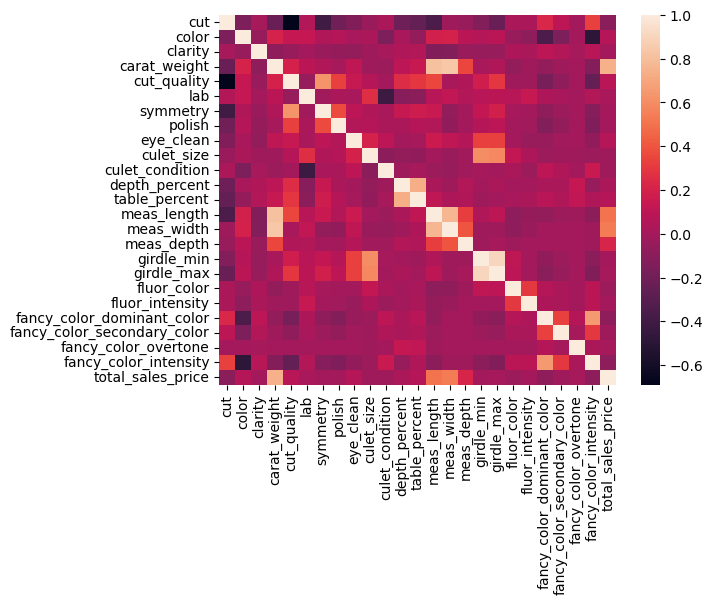

In [57]:
#Lets do a quantitative analysis by feature correlatio
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Initialize MinMaxScaler
ss = MinMaxScaler()

# Used to normalize feature values between 0 and 1
# (helps models that are sensitive to scale)
# Compute correlation matrix
corr = df2.corr()

# Plot correlation heatmap
sns.heatmap(corr)


In [59]:
# Create an empty list to store feature names
features = []

# Loop through all columns in the dataset
for i in df2:
    
    # Exclude the target variable
    if i != 'total_sales_price':
        
        # Add feature column to the list
        features.append(i)

# Print all selected features
print(features)

['cut', 'color', 'clarity', 'carat_weight', 'cut_quality', 'lab', 'symmetry', 'polish', 'eye_clean', 'culet_size', 'culet_condition', 'depth_percent', 'table_percent', 'meas_length', 'meas_width', 'meas_depth', 'girdle_min', 'girdle_max', 'fluor_color', 'fluor_intensity', 'fancy_color_dominant_color', 'fancy_color_secondary_color', 'fancy_color_overtone', 'fancy_color_intensity']


In [61]:
# Define feature matrix (X) and target variable (y)
X = df2[features]                     # Independent variables
y = df2['total_sales_price']          # Target variable (price)

# Check dataset dimensions
print(X.shape)
print(y.shape)

'''
# Manual normalization example (currently not used)

#miniX = np.min(X)
#maxiX = np.max(X)
miniy = np.min(y)
maxiy = np.max(y)

#print(miniX)
print(maxiX)

# Scale X between 0 and 1
#X = (X-miniX)/(maxiX - miniX)

# Scale y between 0 and 1
y = (y-miniy)/(maxiy - miniy)
'''

# Alternative scaling using MinMaxScaler (currently commented)
#X = ss.fit_transform(X)
#y = ss.fit_transform(y.values.reshape(-1,1))

# Confirm shapes remain the same
print(X.shape)
print(y.shape)

(210733, 24)
(210733,)
(210733, 24)
(210733,)


In [63]:
# Use f_regression to evaluate feature importance
from sklearn.feature_selection import SelectKBest as skb
from sklearn.feature_selection import f_regression

# Select all features to view their scores
fs = skb(f_regression, k='all')

# Fit feature selector to data
fs.fit(X, y)

# Print F-score for each feature
for i in range(len(fs.scores_)):
    print('Feature %d: %f' % (i, fs.scores_[i]))
    

Feature 0: 2351.829814
Feature 1: 763.530889
Feature 2: 7.508829
Feature 3: 262784.677705
Feature 4: 1257.053498
Feature 5: 52.120888
Feature 6: 15.295604
Feature 7: 0.797271
Feature 8: 700.757119
Feature 9: 61.000643
Feature 10: 93.893807
Feature 11: 178.268037
Feature 12: 798.068627
Feature 13: 72052.458415
Feature 14: 84132.972035
Feature 15: 10257.338679
Feature 16: 0.257913
Feature 17: 9.431320
Feature 18: 191.866619
Feature 19: 1.709612
Feature 20: 1217.275583
Feature 21: 114.373682
Feature 22: 6.880758
Feature 23: 1492.969054


In [65]:
# Select the 15 best features based on F-regression score

fs = skb(f_regression, k=15)        # Choose top 15 features
Xnew = fs.fit_transform(X, y)       # Transform dataset using selected features

# Convert feature list to numpy array
f = np.array(features)

# Get mask of selected features
filt = fs.get_support()

# Filter feature names
f = f[filt]

# Print selected feature names and count
print(f, len(f))

['cut' 'color' 'carat_weight' 'cut_quality' 'eye_clean' 'culet_condition'
 'depth_percent' 'table_percent' 'meas_length' 'meas_width' 'meas_depth'
 'fluor_color' 'fancy_color_dominant_color' 'fancy_color_secondary_color'
 'fancy_color_intensity'] 15


In [67]:
# Use the full feature set (no feature reduction)
Xnew = X

# Reshape target variable to 2D array for model compatibility
y = y.values.reshape(-1, 1)

# Check shapes of feature matrix and target
print(Xnew.shape)
print(y.shape)

(210733, 24)
(210733, 1)


In [69]:
# Final check of data before modeling

# Print feature matrix and its shape
print(Xnew, Xnew.shape)

# Print target variable and its shape
print(y, y.shape)

        cut  color  clarity  carat_weight  cut_quality  lab  symmetry  polish  \
0        10      1       10          0.09            0    2         4       4   
1        10      1       10          0.09            4    2         4       4   
2        10      1       10          0.09            0    2         4       4   
3        10      1       10          0.09            0    2         4       4   
4        10      1       10          0.09            4    2         4       0   
...     ...    ...      ...           ...          ...  ...       ...     ...   
219698   10      1        7         10.65            0    0         0       0   
219699    9     10        8          5.17            5    0         4       4   
219700   10      1        7         18.07            0    0         0       0   
219701    8     10        5          0.90            5    0         2       2   
219702    7     10       10         10.03            5    0         4       0   

        eye_clean  culet_si

In [71]:
# Split dataset into training and testing sets
from sklearn.model_selection import train_test_split as tts

# 80% training data, 20% testing data
X_train, X_test, y_train, y_test = tts(Xnew, y, test_size=0.2, random_state=40)

# Print training set shapes
print(X_train.shape, y_train.shape)

# Print testing set shapes
print(X_test.shape, y_test.shape)

(168586, 24) (168586, 1)
(42147, 24) (42147, 1)


# Modelling the regression

In [73]:
#for this we can use the inbuilt LinearRegression model in sklearn
from sklearn.linear_model import LinearRegression

mlr = LinearRegression()

mlr.fit(X_train, y_train)

print("Intercept: ",mlr.intercept_)
print("Coeffs: ", list(zip(X, mlr.coef_)))

Intercept:  [52108.02935416]
Coeffs:  [('cut', array([ 6.71497505e+02, -8.58581701e+02,  3.30560273e+02,  3.54345899e+04,
       -4.08336589e+02, -2.91832284e+03,  1.01630519e+02,  1.40222969e+02,
        2.39902030e+02,  4.45004794e+01, -3.59443826e+03, -2.38082963e+02,
       -8.26364256e+01, -2.59557815e+03, -5.33324841e+03, -1.73382967e+02,
       -2.48596259e+01,  3.97878664e+01,  7.40355897e+01,  3.91240544e+01,
       -2.06474416e+03, -3.96749759e+01,  2.72054095e+03,  1.24320925e+02]))]


In [77]:
# Predict target values using the trained model
y_pred_mlr = mlr.predict(X_test)

In [79]:
# Evaluate model performance
from sklearn import metrics

# Calculate Mean Absolute Error
MABE = metrics.mean_absolute_error(y_test, y_pred_mlr)

# Calculate R² score (model accuracy)
r2 = mlr.score(X_test, y_test) * 100

# Print evaluation metrics
print("R squared score:", r2)
print("Mean absolute error:", MABE)

R squared score: 66.18634564855637
Mean absolute error: 4152.997833575048


### Model Performance Interpretation

- **R² Score: 66.19%**  
  The model explains approximately **66% of the variance** in the diamond sales price. This indicates a **moderate predictive ability**, meaning the selected features capture a significant portion of the price variability, but there is still unexplained variation.

- **Mean Absolute Error (MAE): 4152.99**  
  On average, the model's predictions differ from the actual sales price by about **4,153 units**. This represents the typical prediction error magnitude.

**Conclusion:**  
The linear regression model provides **reasonable predictive performance**, but the remaining unexplained variance suggests that **additional features, nonlinear relationships, or more advanced models** could potentially improve prediction accuracy.

# Model number 2: ANN

In [85]:
# Import TensorFlow library
import tensorflow

# Import Sequential model to build neural networks layer-by-layer
from keras.models import Sequential

# Import Dense layer for fully connected neural network layers
from keras.layers import Dense

In [86]:
# Build a neural network model
model = Sequential()

# Input layer + first hidden layer (100 neurons, ReLU activation)
model.add(Dense(units=100, input_dim=24, kernel_initializer='normal', activation='relu'))

# Second hidden layer (50 neurons)
model.add(Dense(units=50, kernel_initializer='normal', activation='relu'))

# Output layer (1 value for price prediction)
model.add(Dense(1, kernel_initializer='normal'))

# Compile model using Mean Squared Error loss for regression
model.compile(loss='mean_squared_error', optimizer='adam')

# Train the model and store training history
history = model.fit(
    X_train, y_train,
    validation_split=0.2,   # Use 20% of training data for validation
    batch_size=2000,        # Number of samples per training step
    epochs=50,              # Number of training iterations
    verbose=1               # Show training progress
)

C:\Users\adyce\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 742106752.0000 - val_loss: 680446976.0000
Epoch 2/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 726041856.0000 - val_loss: 648220096.0000
Epoch 3/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 693313344.0000 - val_loss: 631445504.0000
Epoch 4/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 687655296.0000 - val_loss: 629473472.0000
Epoch 5/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 685468224.0000 - val_loss: 627070848.0000
Epoch 6/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 682567424.0000 - val_loss: 623671360.0000
Epoch 7/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 678258048.0000 - val_loss: 618394048.0000
Epoch 8/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 671299328.0000 - val_loss: 609459008.0000
Epoch 9/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 659212096.0000 - val_loss: 594149312.0000
Epoch 10/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 639587456.0000 - val_loss: 570728640.0000

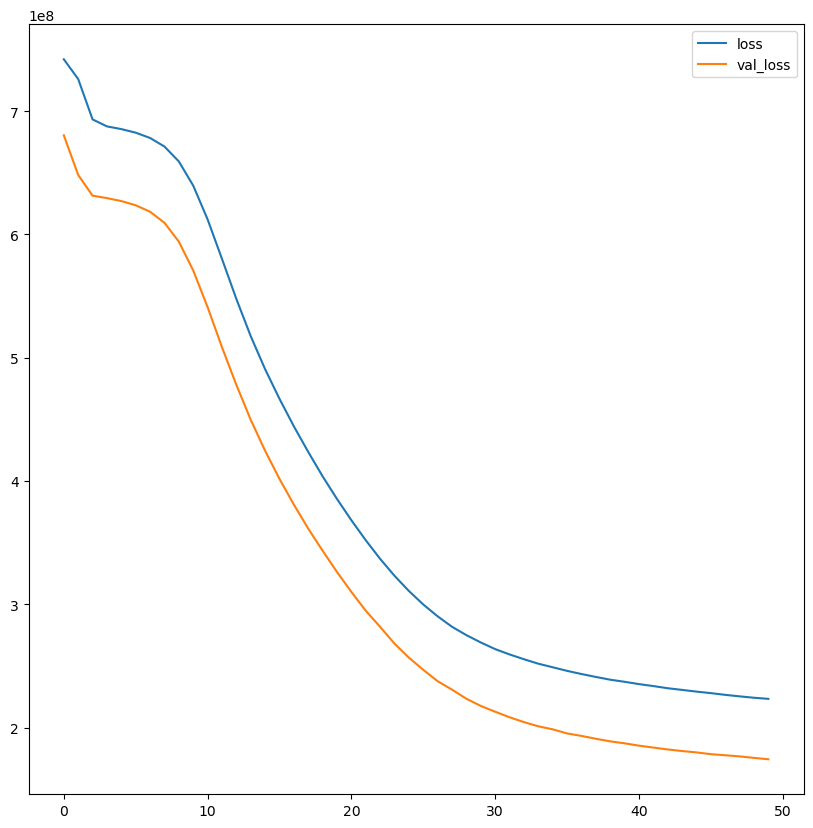

In [89]:
# Plot training history (loss and validation loss)

'''
# Accuracy plots (not used because this is a regression problem)

plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.show()

# Loss plots
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.show()
'''

# Convert training history to DataFrame and plot
pd.DataFrame(history.history).plot(figsize=(10,10))

# Display plot
plt.show(

In [94]:
# Generate predictions on test data
pred = model.predict(X_test)

# Optional: denormalize predictions if scaling was applied
#pred_denorm = pred*(maxiy-miniy) + miniy
#y_test_denorm = y_test*(maxiy-miniy) + miniy

# Import evaluation metric
from sklearn.metrics import r2_score

# Calculate R² score
r2 = r2_score(y_test, pred) * 100

# Print model performance
print("R Squared:", r2)

1318/1318 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
R Squared: 70.50720850710181


### Neural Network Model Performance

- **R² Score: 70.51%**

The neural network model explains approximately **70.5% of the variance** in the diamond sales price. This indicates that the model captures a **strong portion of the relationship between the features and the target variable**.

**Comparison with Linear Regression:**
- Linear Regression R²: **66.19%**
- Neural Network R²: **70.51%**

The neural network shows a **moderate improvement in predictive performance**, suggesting that it is able to capture **more complex relationships and nonlinear patterns** in the data.

**Conclusion:**  
The neural network model performs **better than the linear regression model**, but there is still room for improvement through **feature engineering, hyperparameter tuning, or more advanced architectures**.